In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

RANDOM_STATE = 42


## Import module and data

In [3]:
# 1. load date set
train = pd.read_csv("data/train.csv")

print(f"Train shape: {train.shape}")
train.head()


Train shape: (1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Target Variable Analysis

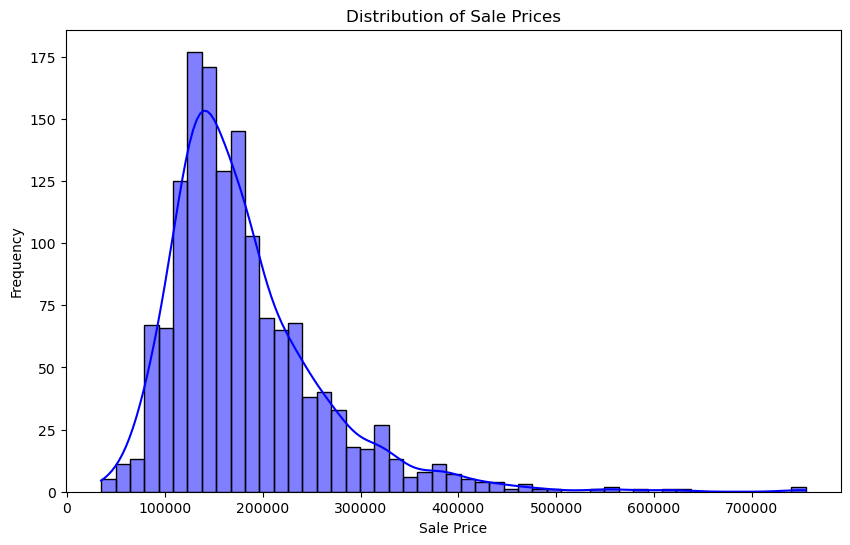

Skewness: 1.88


In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(train['SalePrice'], kde=True, color='blue')
plt.title('Distribution of Sale Prices')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')
plt.show()

print(f"Skewness: {train['SalePrice'].skew():.2f}")

## Find Where the Data is Missing

In [5]:
# Calculate total missing values per column in the training set

missing_count = train.isnull().sum()
missing_percent = (train.isnull().sum() / len(train)) * 100

missing_df = pd.concat([missing_count, missing_percent], axis=1, keys=['Total Missing', 'Percent'])
missing_df = missing_df[missing_df['Total Missing'] > 0].sort_values(by='Total Missing', ascending=False)

print("Columns with missing values in Train Set:")
print(missing_df)

Columns with missing values in Train Set:
              Total Missing    Percent
PoolQC                 1453  99.520548
MiscFeature            1406  96.301370
Alley                  1369  93.767123
Fence                  1179  80.753425
MasVnrType              872  59.726027
FireplaceQu             690  47.260274
LotFrontage             259  17.739726
GarageType               81   5.547945
GarageYrBlt              81   5.547945
GarageFinish             81   5.547945
GarageQual               81   5.547945
GarageCond               81   5.547945
BsmtFinType2             38   2.602740
BsmtExposure             38   2.602740
BsmtFinType1             37   2.534247
BsmtCond                 37   2.534247
BsmtQual                 37   2.534247
MasVnrArea                8   0.547945
Electrical                1   0.068493


***
### Analyze the Top Offenders
When you run that code, you will see a few columns dominating the list with massive amounts of missing data (often over 80% or 90% missing):

PoolQC (Pool Quality)

MiscFeature (Miscellaneous feature like sheds or tennis courts)

Alley (Type of alley access)

Fence (Fence quality)
***

### Fix the Missing Values (Imputation)

In [6]:
def handle_missing_values(df):
    df_clean = df.copy()
    none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
                 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                 'BsmtFinType1', 'BsmtFinType2', 'BsmtExposure', 'BsmtQual', 'BsmtCond']
    for col in none_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna("None")

    zero_cols = ['GarageYrBlt', 'GarageArea', 'GarageCars', 'BsmtFinSF1',
                 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath']
    for col in zero_cols:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].fillna(0)

    if 'LotFrontage' in df_clean.columns:
        df_clean['LotFrontage'] = df_clean.groupby('Neighborhood')['LotFrontage'] \
            .transform(lambda x: x.fillna(x.median()))

    remaining_objects = df_clean.select_dtypes(include=['object']).columns
    for col in remaining_objects:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

    remaining_numeric = df_clean.select_dtypes(include=[np.number]).columns
    for col in remaining_numeric:
        if df_clean[col].isnull().any():
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())

    return df_clean

train_clean = handle_missing_values(train)

print(f"Remaining missing values in Train: {train_clean.isnull().sum().sum()}")



Remaining missing values in Train: 0


## Convert Ordinal Text into Ranked Numbers

In [7]:
def encode_ordinal_features(df):
    df_encoded = df.copy()
    
    qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
    bsmt_exposure_map = {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0}
    bsmt_fin_map = {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0}

    qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
                 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']
    for col in qual_cols:
        if col in df_encoded.columns:
            df_encoded[col] = df_encoded[col].map(qual_map)

    if 'BsmtExposure' in df_encoded.columns:
        df_encoded['BsmtExposure'] = df_encoded['BsmtExposure'].map(bsmt_exposure_map)

    for col in ['BsmtFinType1', 'BsmtFinType2']:
        if col in df_encoded.columns:
            df_encoded[col] = df_encoded[col].map(bsmt_fin_map)

    return df_encoded

train_ordinal = encode_ordinal_features(train_clean)

#### One-Hot Encode the Remaining Text Columns

In [8]:
train_prices = train_ordinal['SalePrice']
train_feats = train_ordinal.drop(['Id', 'SalePrice'], axis=1)
X = pd.get_dummies(train_feats, drop_first=True)
y = train_prices


#### Feature Engineering (Adding Domain Wisdom)

In [9]:
X['TotalSF'] = X['TotalBsmtSF'] + X['1stFlrSF'] + X['2ndFlrSF']
X['TotalBath'] = X['FullBath'] + (0.5 * X['HalfBath']) + X['BsmtFullBath'] + (0.5 * X['BsmtHalfBath'])

X = X.astype(float)

print("Feature Engineering Complete!")

Feature Engineering Complete!


## Visualize the Outliers

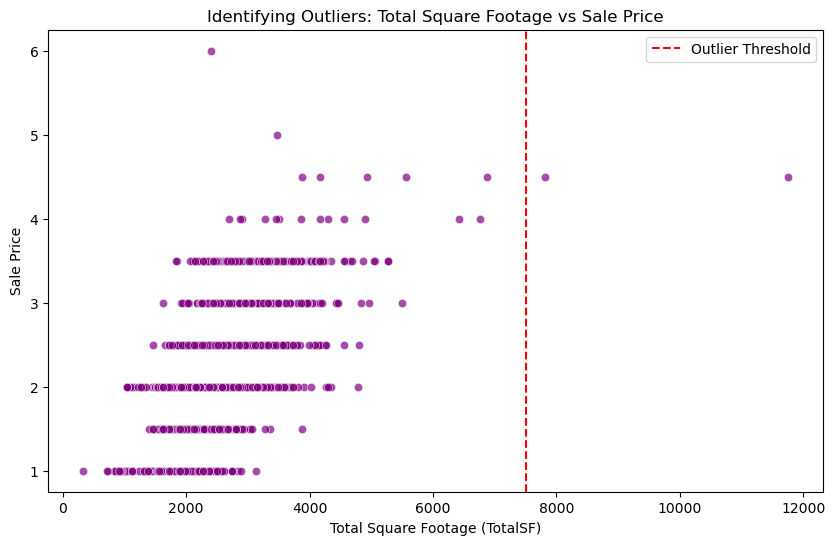

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X['TotalSF'], y=X['TotalBath'], color='purple', alpha=0.7)
plt.title('Identifying Outliers: Total Square Footage vs Sale Price')
plt.xlabel('Total Square Footage (TotalSF)')
plt.ylabel('Sale Price')
plt.axvline(x=7500, color='red', linestyle='--', label='Outlier Threshold')
plt.legend()
plt.show()

### Outliers removal

In [11]:
outliers = X[(X['TotalSF'] > 7500) & (y < 300000)].index
X = X.drop(outliers)
y = y.drop(outliers)

print(f"Dropped {len(outliers)} outlier rows. Final New shape: {X.shape}")

Dropped 2 outlier rows. Final New shape: (1458, 217)


#### Log-Transform the Target Variable

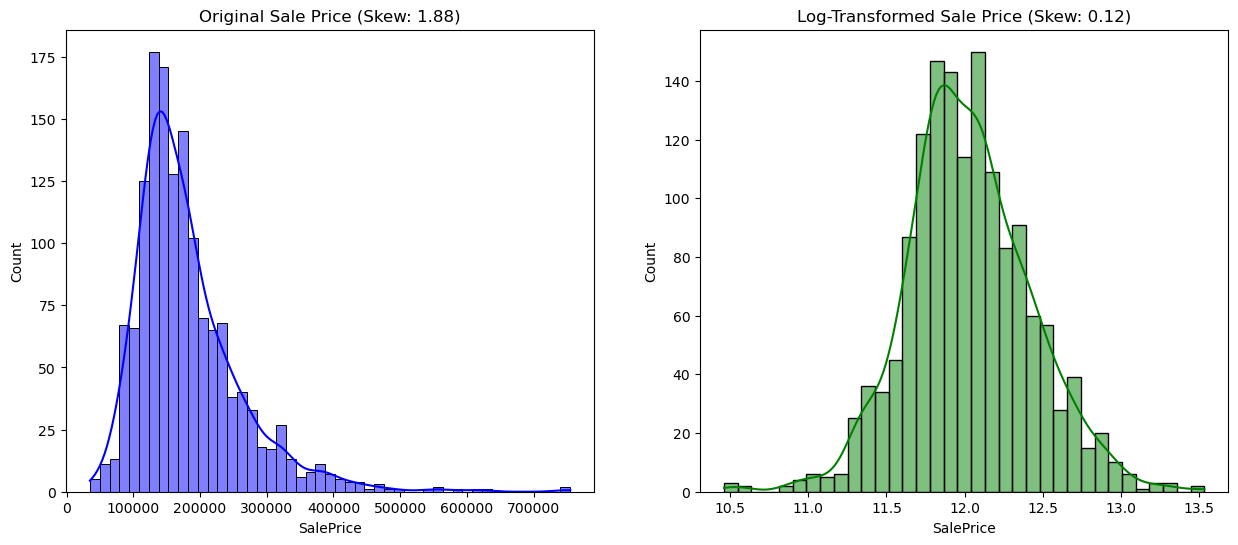

In [13]:
y_log = np.log1p(y)

# Visualize the change
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(y, kde=True, ax=ax[0], color='blue')
ax[0].set_title(f'Original Sale Price (Skew: {y.skew():.2f})')

sns.histplot(y_log, kde=True, ax=ax[1], color='green')
ax[1].set_title(f'Log-Transformed Sale Price (Skew: {y_log.skew():.2f})')

plt.show()

## HONEST evaluation:
 held-out split (this is what was missing before --
 the original notebook reported in-sample/training accuracy as the
 headline metric, which is overly optimistic)

### Train and Test Multiple Models

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_log, test_size=0.15, random_state=RANDOM_STATE
)

ridge = Ridge(alpha=10.0)
lasso = Lasso(alpha=0.0005, max_iter=100000)
gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, random_state=RANDOM_STATE)

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
def rmse_cv(model, X_, y_):
    return np.sqrt(-cross_val_score(model, X_, y_, scoring="neg_mean_squared_error", cv=kf))

print("\n--- 5-Fold CV on training split (log-RMSE) ---")


--- 5-Fold CV on training split (log-RMSE) ---


In [22]:
for name, m in [("Ridge", ridge), ("Lasso", lasso), ("GBR", gbr)]:
    scores = rmse_cv(m, X_train, y_train)
    print(f"{name}: {scores.mean():.4f} (+/- {scores.std():.4f})")


Ridge: 0.1145 (+/- 0.0077)


C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.470e-01, tolerance: 1.570e-02
  model = cd_fast.enet_coordinate_descent(


Lasso: 0.1148 (+/- 0.0083)
GBR: 0.1230 (+/- 0.0094)


In [24]:
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)
gbr.fit(X_train, y_train)

def blended_predict(models, X_):
    r, l, g = models
    return 0.30 * r.predict(X_) + 0.30 * l.predict(X_) + 0.40 * g.predict(X_)

y_pred_log = blended_predict((ridge, lasso, gbr), X_test)
y_pred_dollars = np.expm1(y_pred_log)
y_actual_dollars = np.expm1(y_test)

holdout_mae = mean_absolute_error(y_actual_dollars, y_pred_dollars)
holdout_r2 = r2_score(y_actual_dollars, y_pred_dollars)
print("\n--- HONEST held-out test metrics (15% never seen during training) ---")
print(f"MAE: ${holdout_mae:,.2f}")
print(f"R²:  {holdout_r2:.4f} ({holdout_r2*100:.2f}%)")



--- HONEST held-out test metrics (15% never seen during training) ---
MAE: $12,694.79
R²:  0.9368 (93.68%)


###  Train all models on the full dataset

In [26]:
ridge_final = Ridge(alpha=10.0).fit(X, y_log)
lasso_final = Lasso(alpha=0.0005, max_iter=100000).fit(X, y_log)
gbr_final = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4,
                                       random_state=RANDOM_STATE).fit(X, y_log)

print("Ensemble model trained and ready!")

C:\Users\HP\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.037e-01, tolerance: 2.328e-02
  model = cd_fast.enet_coordinate_descent(


Ensemble model trained and ready!


### Export the Model for Streamlit

In [27]:
os.makedirs("models", exist_ok=True)

joblib.dump(ridge_final, "models/ridge_model.pkl")
joblib.dump(lasso_final, "models/lasso_model.pkl")
joblib.dump(gbr_final, "models/gbr_model.pkl")

joblib.dump(X.columns.tolist(), "models/model_columns.pkl")

feature_medians = X.median().to_dict()
joblib.dump(feature_medians, "models/feature_medians.pkl")

importances = pd.Series(gbr_final.feature_importances_, index=X.columns).sort_values(ascending=False)
joblib.dump(importances, "models/feature_importances.pkl")

metrics = {
    "holdout_mae": holdout_mae,
    "holdout_r2": holdout_r2,
    "mean_price": float(y.mean()),
    "n_features": X.shape[1],
    "n_train_rows": int(X.shape[0]),
}
joblib.dump(metrics, "models/metrics.pkl")

print(f"\nSaved {X.shape[1]} columns to model_columns.pkl (was 36 before the fix)")
print("Top 10 real feature importances:")
print(importances.head(10))
print("\nAll artifacts saved to models/")


Saved 217 columns to model_columns.pkl (was 36 before the fix)
Top 10 real feature importances:
OverallQual     0.376166
TotalSF         0.360321
TotalBath       0.027387
KitchenQual     0.017536
GrLivArea       0.016374
CentralAir_Y    0.016072
YearRemodAdd    0.015509
OverallCond     0.015328
GarageCars      0.014754
LotArea         0.013829
dtype: float64

All artifacts saved to models/
